# Qwen2.5-1.5B × Aya-Bengali leaderboard — chord-tight-clean vs AdamW (r=256, 9000 steps)

New **dataset axis**: Bengali instruction-tuning (`CohereForAI/aya_collection_language_split`, config `bengali`), distinct from the code/math datasets. Does chord-tight-clean's behavior carry to a non-English, non-code SFT mixture? Qwen2.5-1.5B × Aya-Bengali × r=256 × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × H200. `max_steps=9000`, `eval_every=250`.

- **AdamW** (speed target): η ∈ {1e-5, 3e-5, 1e-4, 3e-4, 1e-3}
- **chord-tight-clean k=1, ns=8, ε_rel=1e-3**: η ∈ {3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1}

Labels/colors from the shared `canonical_label` / `compare_variants_figure` machinery; run membership from `lora_playground.workloads` (same source as the leaderboard doc).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Repo root by marker-walk, so this notebook works from any subdir.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import leaderboard_panel, canonical_label

# Run membership comes from the shared registry (lora_playground.workloads) — the
# SAME source the leaderboard doc uses, so notebook and doc cannot drift. Cells are
# leaderboard_panel(model, dataset, rank, ...) + an optional label_filter(label, cfg).

def ns_of(cfg):
    oc = cfg.get('optimizer_config') or {}
    return cfg.get('muon_ns_steps', oc.get('ns_steps'))

def picard_of(cfg):
    return cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override')) or 1

def is_curv(label):
    # curvature-whitening / SOAP-curv / KL-Shampoo arms.
    return ('SOAP-curv' in label) or ('KL-Shampoo' in label) or ('+curv' in label)

## r=256 — chord-tight-clean (ns=8, k=1, ε_rel=1e-3) vs AdamW

`allow_partial=True`; re-run as the sweep fills in (full results ~4–6 h).

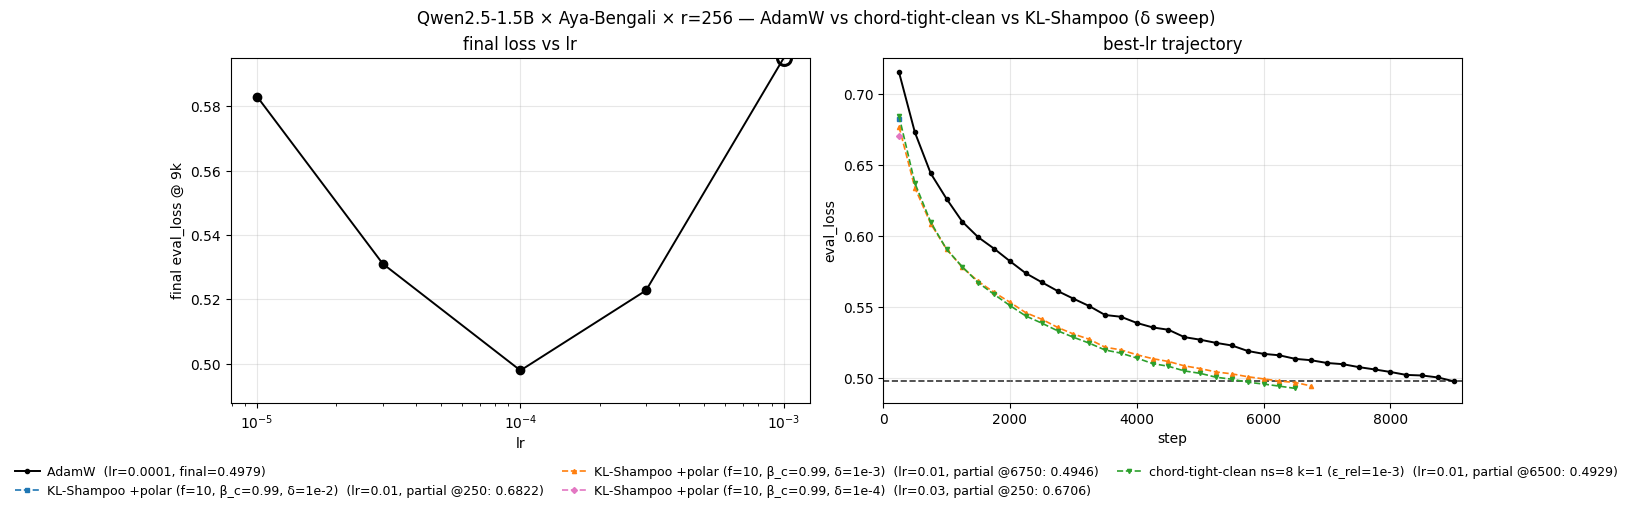

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,None,None


In [2]:
_fig, _tdf, sdf = leaderboard_panel('Qwen/Qwen2.5-1.5B', 'bengali', 256,
    'Qwen2.5-1.5B × Aya-Bengali × r=256 — AdamW vs chord-tight-clean vs KL-Shampoo (δ sweep)',
    figsize=(13, 5))
plt.show()
sdf